In [13]:
!pip install pandas
!pip install numpy
!pip install google-play-scraper
import numpy as np
import pandas as pd
from google_play_scraper import Sort, reviews
from google_play_scraper import app

In [15]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd # Ensure pandas is imported if not already

# Fungsi untuk mendapatkan ulasan
def get_reviews(app_id, count):
    print(f"Memulai proses pengambilan {count} ulasan untuk {app_id}...")
    reviews_data = reviews_all(
        app_id,
        lang='id',  # Bahasa ulasan (Indonesia)
        sort=Sort.MOST_RELEVANT,  # Urutan ulasan
        count=count  # Jumlah ulasan yang ingin diambil
    )
    print(f"Proses untuk {app_id} selesai.")
    return reviews_data

# --- Konfigurasi Aplikasi ---

# Daftar aplikasi yang ingin diambil
apps_to_scrape = {
    "DANA": "id.dana",
    "OVO": "ovo.id"
}

# Jumlah ulasan yang ingin diambil per aplikasi
reviews_count = 3000

# --- Proses Pengambilan Data ---
all_reviews_list = [] # Initialize list to store all reviews

# Loop untuk mengambil data dari setiap aplikasi
for app_name, app_id in apps_to_scrape.items():

    print(f"\n=======================================================")
    print(f"MENGAMBIL ULASAN UNTUK: {app_name} (ID: {app_id})")
    print(f"=======================================================")

    # Mendapatkan ulasan menggunakan fungsi Anda
    app_reviews = get_reviews(app_id, reviews_count)

    # Add app_name to each review before appending
    for review in app_reviews:
        review['app_name'] = app_name
    all_reviews_list.extend(app_reviews)

    print(f"\n--- Hasil Ulasan untuk {app_name} ---")
    # Menampilkan jumlah ulasan yang berhasil diambil
    print(f"-> Jumlah ulasan {app_name} yang berhasil diambil: {len(app_reviews)}")

print("\n=======================================================")
print(f"Semua proses pengambilan ulasan telah selesai. Total ulasan: {len(all_reviews_list)}")
print("=======================================================")


MENGAMBIL ULASAN UNTUK: DANA (ID: id.dana)
Memulai proses pengambilan 3000 ulasan untuk id.dana...
Proses untuk id.dana selesai.

--- Hasil Ulasan untuk DANA ---
-> Jumlah ulasan DANA yang berhasil diambil: 99000

MENGAMBIL ULASAN UNTUK: OVO (ID: ovo.id)
Memulai proses pengambilan 3000 ulasan untuk ovo.id...
Proses untuk ovo.id selesai.

--- Hasil Ulasan untuk OVO ---
-> Jumlah ulasan OVO yang berhasil diambil: 144000

Semua proses pengambilan ulasan telah selesai. Total ulasan: 243000


In [17]:
data = pd.DataFrame(np.array(all_reviews_list), columns=['content'])
data = data.join(pd.DataFrame(data.pop('content').tolist()))
data.head(6000)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,57e8d827-04e3-489a-bbdc-b0db7e74135f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,buruk bangettt!!! aku awalnya pake aman aman a...,1,260,2.103.1,2025-11-08 22:28:49,"Hi Kak, Kami turut prihatin atas adanya kehila...",2025-11-09 00:40:33,2.103.1,DANA
1,f2dd45ef-b5f8-47a6-8ba3-e24051b98ff7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Selama saya menggunakan aplikasi ini, menjadi ...",5,318,2.103.1,2025-11-09 23:53:17,None,NaT,2.103.1,DANA
2,2c194ee0-89d1-410d-a9c4-72af20954bdd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"genap sebulan tgl 4 ini, dimana saldo dana+ ti...",1,239,2.103.1,2025-11-03 17:44:37,"Hi Kak Fajar, mohon maaf atas kendala terkait ...",2025-11-03 20:00:18,2.103.1,DANA
3,028672e3-988b-48e4-9f39-f55ae0c891a4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya semuanya bagus bagus ajahh, hanya s...",5,719,2.103.1,2025-11-09 15:48:06,None,NaT,2.103.1,DANA
4,a34a5516-ed3d-4368-b2d3-569af65a5fc9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah sekali kembalikan uang yang sudah terpot...,2,100,2.103.1,2025-11-01 23:47:36,None,NaT,2.103.1,DANA
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0efef521-2bc6-47dc-965c-5b715082809b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dompet digital yg sangat membantu saat bertran...,5,0,2.99.1,2025-10-14 05:04:56,None,NaT,2.99.1,DANA
5996,af2da2eb-f292-4c4e-a05d-5dc5c25177e3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Napa gak bisa masuk ke dana, mana uang masih a...",1,0,2.94.1,2025-08-31 02:39:24,"Hi Kak Lubis, kami memahami yg dialami. Saat i...",2025-08-31 03:18:32,2.94.1,DANA
5997,989e9442-385e-43c9-8a1f-ce51a0f67442,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,loading nya lama sekali aku masukk koneksi jar...,4,0,2.97.0,2025-09-17 10:44:34,"Hi Kak Heri, maaf ya kalau sempat bikin kurang...",2025-09-17 12:03:45,2.97.0,DANA
5998,0c6b6d18-de24-4a71-8afc-2ee1d803fd8e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa setelah premium aplikasi malah susah di...,2,15,2.99.1,2025-10-07 01:22:53,"Hi Kak Suti, maaf ya kalau sempat bikin kurang...",2025-10-07 03:08:40,2.99.1,DANA


In [18]:
data = data.rename(columns={'content' : 'ulasan', 'score':'rating'})
data.head()

,reviewId,userName,userImage,ulasan,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,57e8d827-04e3-489a-bbdc-b0db7e74135f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,buruk bangettt!!! aku awalnya pake aman aman a...,1,260,2.103.1,2025-11-08 22:28:49,"Hi Kak, Kami turut prihatin atas adanya kehila...",2025-11-09 00:40:33,2.103.1,DANA
1,f2dd45ef-b5f8-47a6-8ba3-e24051b98ff7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Selama saya menggunakan aplikasi ini, menjadi ...",5,318,2.103.1,2025-11-09 23:53:17,None,NaT,2.103.1,DANA
2,2c194ee0-89d1-410d-a9c4-72af20954bdd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"genap sebulan tgl 4 ini, dimana saldo dana+ ti...",1,239,2.103.1,2025-11-03 17:44:37,"Hi Kak Fajar, mohon maaf atas kendala terkait ...",2025-11-03 20:00:18,2.103.1,DANA
3,028672e3-988b-48e4-9f39-f55ae0c891a4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya semuanya bagus bagus ajahh, hanya s...",5,719,2.103.1,2025-11-09 15:48:06,None,NaT,2.103.1,DANA
4,a34a5516-ed3d-4368-b2d3-569af65a5fc9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah sekali kembalikan uang yang sudah terpot...,2,100,2.103.1,2025-11-01 23:47:36,None,NaT,2.103.1,DANA


In [19]:
!pip install nltk
!pip install Sastrawi
!pip install pandas
!pip install numpy
!pip install regex
!pip install TextBlob

In [20]:
import pandas as pd
import re
import numpy as np
import string
import textblob

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
df= pd.read_excel("/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_3k.xlsx")

In [45]:
columns_to_drop = ['reviewId', 'userImage']

# Menghapus kolom-kolom yang disebutkan
df = df.drop(columns=columns_to_drop, axis=1)

In [46]:
df.head(6000)

,userName,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,Pengguna Google,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,Pengguna Google,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,Pengguna Google,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,Pengguna Google,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,Pengguna Google,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus
...,...,...,...,...,...,...,...,...,...,...,...,...
5957,Pengguna Google,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...
5958,Pengguna Google,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...
5959,Pengguna Google,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...
5960,Pengguna Google,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...


In [47]:
!pip install nltk
!pip install Sastrawi
!pip install pandas
!pip install numpy
!pip install regex
import pandas as pd
import re

In [48]:
import pandas as pd
from textblob import TextBlob

# Muat data dari CSV
df = pd.read_excel('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_3k.xlsx')

In [49]:
df.head()

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus


In [50]:
import pandas as pd
# Fungsi untuk memberikan label
def assign_label(rating):
    try:
        rating = int(rating)
        if rating >= 3.0:
            return 'positif'
        if rating < 3.0:
            return 'negatif'
    except ValueError:
        return 'nilai_invalid'

# Rename 'score' column to 'rating' for consistency with the intended logic
df = df.rename(columns={'score': 'rating'})

# Contoh penggunaan pada kolom 'label' bersarkan rating
df['label'] = df['rating'].apply(assign_label)

# Contoh tampilan DataFrame setelah label ditambahkan
print(df[['label', 'rating']])

        label  rating
0     positif       5
1     negatif       2
2     negatif       1
3     negatif       1
4     positif       5
...       ...     ...
5957  positif       5
5958  positif       5
5959  positif       5
5960  negatif       1
5961  negatif       1

[5962 rows x 2 columns]


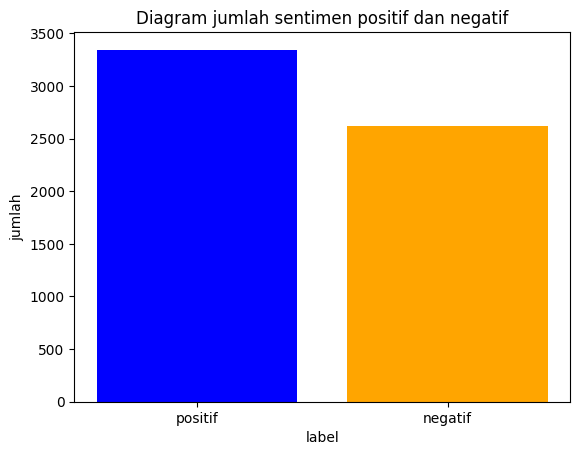

Jumlah sentimen positif: 3345
Jumlah sentimen negatif: 2617


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

jumlah_positif = df[df['label'] == 'positif'].shape[0]
jumlah_negatif = df[df['label'] == 'negatif'].shape[0]

labels = ['positif','negatif']
jumlah = [jumlah_positif, jumlah_negatif]

# Fixed typo: color -> color
plt.bar(labels, jumlah, color=['blue', 'orange'])
plt.xlabel('label')
plt.ylabel('jumlah')
# Fixed typo: tittle -> title
plt.title('Diagram jumlah sentimen positif dan negatif')
plt.show()

print(f"Jumlah sentimen positif: {jumlah_positif}")
print(f"Jumlah sentimen negatif: {jumlah_negatif}")

In [52]:
df.head(6000)

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...


In [53]:
# Menampilkan Data
df.to_excel('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_3k.xlsx', index = False)
df

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...


In [54]:
import string
import numpy as np

In [55]:
data = df['content']

In [56]:
def clean_text(text):
  #baris untuk menghapus username
  pattern = re.compile(r'@\w+')
  text = re.sub(pattern, ' ', text)
  text = re.sub('@[^\s]+',' ', text)
  #Menghapus URL:
  text = re.sub(r"(?:\|http?\://|https?\://|www)\S+"," ", text)
  #Menghapus Karakter Spesial
  text = text.translate(str.maketrans('', '', string.punctuation))
  #Menghapus Tag HTML
  text = re.sub('<.*>', ' ', text)
  #Menghapus Non-Alfabet
  text = re.sub('[^a-zA-Z]',' ', text)
  text = re.sub("\n"," ", text)
  #Konversi ke Huruf Kecil:
  text = text.lower()
  #Menghapus Kata Pendek (Satu Karakter):
  text = re.sub(r"\b[a-zA-Z]\b", " ", text)
  text =' '.join(text.split())
  text = re.sub(r'\@([\w]+)',' ', text)
  # Tahap-4_alt-2: konversi tagar ke kalimat (pemisahan string berdasarkan huruf kapital)**
  text = re.sub(r'((?<=[a-z])[A-Z]|[A-Z](?=[a-z]))', ' \\1', text)
  text = re.sub(r'([A-Z])(?<=[a-z]\\1|[A-Za-z]\\1(?=[a-z]))',' \\1', text)
  # Tahap-5: simbol
  text = re.sub(r'[-!$%^&*@#()_+|~=`{}\[\]";\'<>?,.\/]', ' ', text)
  # Tahap-6: angka
  text = re.sub(r'[0-9]+',' ', text)
  # Tahap-7: koreksi duplikasi tiga karakter beruntun atau lebih (contoh. yukkk)
  text = re.sub(r'([a-zA-Z])\1\1','\\1', text)
  # Tahap-8: spasi ganda (atau lebih) menjadi satu spasi
  text = re.sub(' +', ' ', text)
  # Tahap-9: spasi di awal dan akhir kalimat
  text = re.sub(r'^[ ]|[ ]$',' ', text)
  # Tahap-10: konversi ke karakter huruf kecil
  text = text.lower()
  return text

import pandas as pd
from bs4 import BeautifulSoup
# Fungsi untuk menghapus tag HTML dari komentar
def hapus_tag_html(teks):
    soup = BeautifulSoup(teks, 'html.parser')
    teks_tanpa_html = soup.get_text(separator=' ')
    return teks_tanpa_html

# Membersihkan tag HTML dari kolom komentar
# Mengganti 'ulasan' dengan 'content' karena itu adalah nama kolom yang benar
df['content'] = df['content'].apply(hapus_tag_html)
df['content'] = df['content'].apply(clean_text)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2584607787.py:5: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('@[^\s]+',' ', text)


In [57]:
# clean = df['text']:
# Ini adalah langkah pertama, di mana kolom 'text' dari DataFrame df disalin ke variabel clean.
# clean sekarang berisi teks mentah yang akan dibersihkan.
# df['text'] = [clean_text(i) for i in clean]:
# Ini adalah langkah untuk membersihkan teks.
# List comprehension digunakan di sini untuk mengaplikasikan fungsi clean_text pada setiap elemen dalam list clean.
# Fungsi ini membersihkan teks sesuai dengan langkah-langkah yang telah dijelaskan sebelumnya.

df['clean'] = [clean_text(i) for i in data]
clean = df['content']

In [58]:
df = df[df['clean']!='']
df.head(6000)

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...


In [59]:
# Menyimpan Data Cleaning
df.to_excel('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_cleaning.xlsx', index = False)

In [62]:
# Memanggil Data yang sudah di simpan tadi
df = pd.read_excel("/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_cleaning.xlsx")

In [63]:
df.head(6000)

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...


In [64]:
import nltk
nltk.download('all')
from nltk.tokenize import word_tokenize

def tokenize_text(text):
  token = nltk.tokenize.word_tokenize(text)
  return token

df['token'] = df['clean'].apply(tokenize_text)

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [67]:
df.to_csv('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_tokenize.csv', index = False)

In [66]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()
data = stopwords
print(data)

def stopwords_text(tokens):
  cleaned_token =[]
  for token in tokens:
    if token not in data:
      cleaned_token.append(token)
  return cleaned_token
df['stop'] = df['token'].apply(stopwords_text)

['yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara', 'dia', 'dua', 'ia', 'seperti', 'jika', 'jika', 'sehingga', 'kembali', 'dan', 'tidak', 'ini', 'karena', 'kepada', 'oleh', 'saat', 'harus', 'sementara', 'setelah', 'belum', 'kami', 'sekitar', 'bagi', 'serta', 'di', 'dari', 'telah', 'sebagai', 'masih', 'hal', 'ketika', 'adalah', 'itu', 'dalam', 'bisa', 'bahwa', 'atau', 'hanya', 'kita', 'dengan', 'akan', 'juga', 'ada', 'mereka', 'sudah', 'saya', 'terhadap', 'secara', 'agar', 'lain', 'anda', 'begitu', 'mengapa', 'kenapa', 'yaitu', 'yakni', 'daripada', 'itulah', 'lagi', 'maka', 'tentang', 'demi', 'dimana', 'kemana', 'pula', 'sambil', 'sebelum', 'sesudah', 'supaya', 'guna', 'kah', 'pun', 'sampai', 'sedangkan', 'selagi', 'sementara', 'tetapi', 'apakah', 'kecuali', 'sebab', 'selain', 'seolah', 'seraya', 'seterusnya', 'tanpa', 'agak', 'boleh', 'dapat', 'dsb', 'dst', 'dll', 'dahulu', 'dulunya', 'anu', 'demikian', 'tapi', 'ingin', 'juga', 'nggak', 'mari', 'nanti', 'melainkan', '

In [68]:
# Menyimpan stopword
df.to_csv('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/ulasan_dana_ovo_stopword.csv', index =False)
df

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean,token,stop
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...,"[dana, sangat, bagus, terpercaya, dan, mudah, ...","[dana, sangat, bagus, terpercaya, mudah, trans..."
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...,"[tolong, di, perbaiki, lagi, dana, nya, soal, ...","[perbaiki, dana, nya, soal, nya, mengisi, dana..."
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah,"[apk, sampah]","[apk, sampah]"
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...,"[tf, ke, bank, lain, lewat, dana, malah, pendi...","[tf, bank, lewat, dana, malah, pending, suruh,..."
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus,[bagus],[bagus]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...,"[saya, kasih, bintang, tolong, benahi, kesalah...","[kasih, bintang, benahi, kesalahan, ovo, top, ..."
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...,"[kuberikan, bintang, untuk, keburukan, nya, ad...","[kuberikan, bintang, keburukan, nya, admin, ny..."
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...,"[sorry, nih, gw, kasih, bintang, biar, cepat, ...","[sorry, nih, gw, kasih, bintang, biar, cepat, ..."
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...,"[meskipun, sudah, pencet, link, tetep, ga, bis...","[meskipun, pencet, link, tetep, ga, login, bed..."


In [69]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stemming_text(tokens):
  hasil = [stemmer.stem(token)for token in tokens]
  return hasil

df['stemming'] = df['stop'].apply(lambda x: stemming_text(x))
clean = df['stemming']

In [70]:
df.head(6000)

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean,token,stop,stemming
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...,"[dana, sangat, bagus, terpercaya, dan, mudah, ...","[dana, sangat, bagus, terpercaya, mudah, trans...","[dana, sangat, bagus, percaya, mudah, transaks..."
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...,"[tolong, di, perbaiki, lagi, dana, nya, soal, ...","[perbaiki, dana, nya, soal, nya, mengisi, dana...","[baik, dana, nya, soal, nya, isi, dana, rp, hi..."
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah,"[apk, sampah]","[apk, sampah]","[apk, sampah]"
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...,"[tf, ke, bank, lain, lewat, dana, malah, pendi...","[tf, bank, lewat, dana, malah, pending, suruh,...","[tf, bank, lewat, dana, malah, pending, suruh,..."
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus,[bagus],[bagus],[bagus]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasih bintang tolong benahi kesalahan di ...,5,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,saya kasih bintang tolong benahi kesalahan di ...,"[saya, kasih, bintang, tolong, benahi, kesalah...","[kasih, bintang, benahi, kesalahan, ovo, top, ...","[kasih, bintang, benah, salah, ovo, top, up, m..."
5958,ccfba821-a16d-4027-825f-f6110f144765,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kuberikan bintang untuk keburukan nya admin ny...,5,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,kuberikan bintang untuk keburukan nya admin ny...,"[kuberikan, bintang, untuk, keburukan, nya, ad...","[kuberikan, bintang, keburukan, nya, admin, ny...","[beri, bintang, keburu, nya, admin, nya, ga, n..."
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sorry nih gw kasih bintang biar cepat di respo...,5,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat di respo...,"[sorry, nih, gw, kasih, bintang, biar, cepat, ...","[sorry, nih, gw, kasih, bintang, biar, cepat, ...","[sorry, nih, gw, kasih, bintang, biar, cepat, ..."
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,meskipun sudah pencet link tetep ga bisa login...,1,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meskipun sudah pencet link tetep ga bisa login...,"[meskipun, sudah, pencet, link, tetep, ga, bis...","[meskipun, pencet, link, tetep, ga, login, bed...","[meski, pencet, link, tetep, ga, login, beda, hp]"


In [71]:
import os

# Define the directory path (ensure consistency with previous save operation)
save_directory = '/content/drive/MyDrive/SKRIPSI/CUST1/DATA'

# Create the directory if it does not exist (optional, as it should exist from previous step, but good practice)
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Direktori '{save_directory}' berhasil dibuat.")
else:
    print(f"Direktori '{save_directory}' sudah ada.")

# Menyimpan Data Steeming
df.to_csv(os.path.join(save_directory, 'ulasan_dana_ovo_stemming.csv'), index =False)

Direktori '/content/drive/MyDrive/SKRIPSI/CUST1/DATA' sudah ada.


In [72]:
def join(text):
  text = " ".join ([char for char in text])
  return text

In [73]:
df['ulasan_sesudah_diprocessing'] = df['stemming'].apply(lambda x: join(x))
df.head()

,reviewId,userName,userImage,content,rating,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,clean,token,stop,stemming,ulasan_sesudah_diprocessing
0,bfe5c401-5ece-4210-a985-973662c82fcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dana sangat bagus terpercaya dan mudah transak...,5,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus terpercaya dan mudah transak...,"[dana, sangat, bagus, terpercaya, dan, mudah, ...","[dana, sangat, bagus, terpercaya, mudah, trans...","[dana, sangat, bagus, percaya, mudah, transaks...",dana sangat bagus percaya mudah transaksi dana...
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di perbaiki lagi dana nya soal nya saya...,2,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,tolong di perbaiki lagi dana nya soal nya saya...,"[tolong, di, perbaiki, lagi, dana, nya, soal, ...","[perbaiki, dana, nya, soal, nya, mengisi, dana...","[baik, dana, nya, soal, nya, isi, dana, rp, hi...",baik dana nya soal nya isi dana rp hilang enta...
2,a71ab781-0710-4ce6-b857-4af755a50567,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk sampah,1,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah,"[apk, sampah]","[apk, sampah]","[apk, sampah]",apk sampah
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tf ke bank lain lewat dana malah pending suruh...,1,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf ke bank lain lewat dana malah pending suruh...,"[tf, ke, bank, lain, lewat, dana, malah, pendi...","[tf, bank, lewat, dana, malah, pending, suruh,...","[tf, bank, lewat, dana, malah, pending, suruh,...",tf bank lewat dana malah pending suruh nunggu ...
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus,[bagus],[bagus],[bagus],bagus


In [83]:
# Menyimpan Hasil Preprocessing
df.to_csv("/content//drive/MyDrive/SKRIPSI/CUST1/DATA/Hasil_ulasan_sesudah_dipreprocessing_fix.csv", index = False)

In [84]:
df.drop("userName", axis=1, inplace=True, errors='ignore')
df.drop("content", axis=1, inplace=True, errors='ignore')
df.drop("clean", axis=1, inplace=True, errors='ignore')
df.drop("token", axis=1, inplace=True, errors='ignore')
df.drop("stop", axis=1, inplace=True, errors='ignore')
df.drop("stemming", axis=1, inplace=True, errors='ignore')
df.drop("rating", axis=1, inplace=True, errors='ignore')

In [85]:
df.head(6000)

,reviewId,userImage,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,ulasan_sesudah_diprocessing,hasil_ulasan_klasifikasi_svm
0,bfe5c401-5ece-4210-a985-973662c82fcc,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus percaya mudah transaksi dana...,positif
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,baik dana nya soal nya isi dana rp hilang enta...,negatif
2,a71ab781-0710-4ce6-b857-4af755a50567,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah,negatif
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf bank lewat dana malah pending suruh nunggu ...,negatif
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus,positif
...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,kasih bintang benah salah ovo top up masuk tun...,positif
5958,ccfba821-a16d-4027-825f-f6110f144765,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,beri bintang keburu nya admin nya ga ngotak ke...,positif
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,https://play-lh.googleusercontent.com/EGemoI2N...,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat response...,negatif
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,https://play-lh.googleusercontent.com/EGemoI2N...,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meski pencet link tetep ga login beda hp,negatif


In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Persiapan Data ---
# Memastikan tidak ada nilai NaN (kosong) di kolom ulasan
df['ulasan_sesudah_diprocessing'] = df['ulasan_sesudah_diprocessing'].fillna('')

# --- Poin 2: Perbaikan Rasio Train-Test Split ---
# Membagi data: 80% data latih, 20% data uji
# Menambahkan 'stratify' untuk menjaga keseimbangan proporsi label
X_train, X_test, y_train, y_test = train_test_split(
    df['ulasan_sesudah_diprocessing'],
    df['label'],
    test_size=0.2,  # Diubah dari 0.7 menjadi 0.2
    random_state=125,
    stratify=df['label'] # Ditambahkan untuk hasil yang lebih stabil
)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")
print("-" * 30)

# --- Proses TF-IDF ---
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- Inisialisasi dan Latih Model SVM ---
print("Memulai training model SVM...")
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
print("Training model selesai.")
print("-" * 30)

# --- Prediksi pada Data Uji ---
y_pred = svm_model.predict(X_test_tfidf)

# --- Evaluasi Performa Model ---
accuracy = accuracy_score(y_test, y_pred)
# Simpan confusion matrix untuk visualisasi nanti
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Tampilkan hasil evaluasi
print(f'Accuracy (Akurasi): {accuracy:.2f}\n')
print('Confusion Matrix (Text):')
print(conf_matrix)
print('\nClassification Report:')
print(class_report)
print("-" * 30)

# --- Poin 1 (Persiapan): Prediksi pada seluruh dataset untuk analisis perbandingan ---
# Kita gunakan model yang sudah dilatih untuk memprediksi sentimen semua data
print("Memprediksi sentimen pada seluruh data...")
df['hasil_ulasan_klasifikasi_svm'] = svm_model.predict(vectorizer.transform(df['ulasan_sesudah_diprocessing']))

print("Contoh hasil prediksi pada DataFrame:")
print(df[['app_name', 'label', 'hasil_ulasan_klasifikasi_svm']].head())

Jumlah data latih: 4769
Jumlah data uji: 1193
------------------------------
Memulai training model SVM...
Training model selesai.
------------------------------
Accuracy (Akurasi): 0.85

Confusion Matrix (Text):
[[460  64]
 [115 554]]

Classification Report:
              precision    recall  f1-score   support

     negatif       0.80      0.88      0.84       524
     positif       0.90      0.83      0.86       669

    accuracy                           0.85      1193
   macro avg       0.85      0.85      0.85      1193
weighted avg       0.85      0.85      0.85      1193

------------------------------
Memprediksi sentimen pada seluruh data...
Contoh hasil prediksi pada DataFrame:
  app_name    label hasil_ulasan_klasifikasi_svm
0     DANA  positif                      positif
1     DANA  negatif                      negatif
2     DANA  negatif                      negatif
3     DANA  negatif                      negatif
4     DANA  positif                      positif


Membuat visualisasi Confusion Matrix...
Visualisasi confusion matrix disimpan sebagai 'confusion_matrix_svm.png'


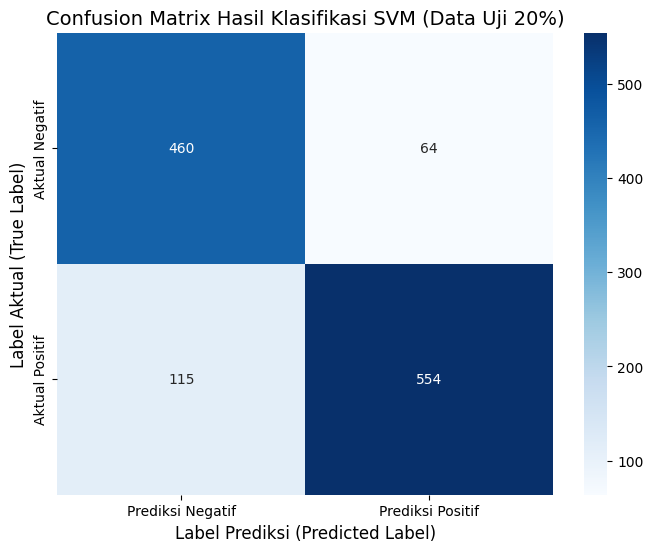

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Confusion Matrix
print("Membuat visualisasi Confusion Matrix...")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Negatif', 'Prediksi Positif'],
            yticklabels=['Aktual Negatif', 'Aktual Positif'])
plt.title('Confusion Matrix Hasil Klasifikasi SVM (Data Uji 20%)', fontsize=14)
plt.ylabel('Label Aktual (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.savefig('confusion_matrix_svm.png')
print("Visualisasi confusion matrix disimpan sebagai 'confusion_matrix_svm.png'")

In [88]:
df.head(6000)

,reviewId,userImage,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,label,ulasan_sesudah_diprocessing,hasil_ulasan_klasifikasi_svm
0,bfe5c401-5ece-4210-a985-973662c82fcc,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:52:05,NaN,NaT,2.103.1,DANA,positif,dana sangat bagus percaya mudah transaksi dana...,positif
1,d1d1f18b-bc2c-4250-9578-18a47ba73778,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:51:16,"Hi Kak, kami turut prihatin atas adanya kehila...",2025-11-14 08:52:45,2.103.1,DANA,negatif,baik dana nya soal nya isi dana rp hilang enta...,negatif
2,a71ab781-0710-4ce6-b857-4af755a50567,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-11-14 07:49:16,"Hi Kak, maaf jika ada pengalaman yg kurang men...",2025-11-14 08:29:09,NaN,DANA,negatif,apk sampah,negatif
3,92619c33-74dd-4b81-8f83-e0d2eba8914e,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:48:33,"Hi Kak Nurul, kami memahami kekecewaan Kakak t...",2025-11-14 09:04:15,2.103.1,DANA,negatif,tf bank lewat dana malah pending suruh nunggu ...,negatif
4,52f01ae6-c17d-4eb6-827c-cfe083f4549f,https://play-lh.googleusercontent.com/EGemoI2N...,0,2.103.1,2025-11-14 07:47:55,NaN,NaT,2.103.1,DANA,positif,bagus,positif
...,...,...,...,...,...,...,...,...,...,...,...,...
5957,43353083-7c66-481a-817d-068e742d3570,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-10-09 06:10:23,NaN,NaT,NaN,OVO,positif,kasih bintang benah salah ovo top up masuk tun...,positif
5958,ccfba821-a16d-4027-825f-f6110f144765,https://play-lh.googleusercontent.com/EGemoI2N...,0,NaN,2025-10-09 05:49:47,NaN,NaT,NaN,OVO,positif,beri bintang keburu nya admin nya ga ngotak ke...,positif
5959,a18d9037-b02b-48c1-9193-9e993be9b9ff,https://play-lh.googleusercontent.com/EGemoI2N...,978,3.144.0,2025-10-09 05:29:49,NaN,NaT,3.144.0,OVO,positif,sorry nih gw kasih bintang biar cepat response...,negatif
5960,82f86cf9-5f79-4492-804c-b908be6a11ba,https://play-lh.googleusercontent.com/EGemoI2N...,1,3.144.0,2025-10-09 04:42:40,NaN,NaT,3.144.0,OVO,negatif,meski pencet link tetep ga login beda hp,negatif


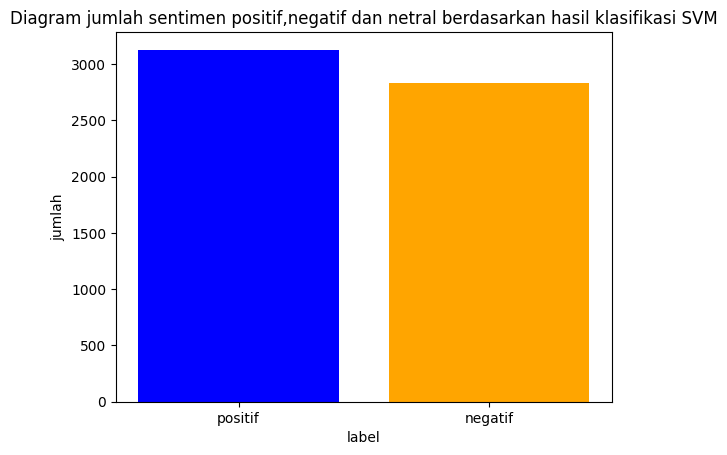

Jumlah sentimen positif: 3128
Jumlah sentimen negatif: 2834


In [89]:
import pandas as pd
import matplotlib.pyplot as plt

jumlah_positif = df[df['hasil_ulasan_klasifikasi_svm'] == 'positif'].shape[0]
jumlah_negatif = df[df['hasil_ulasan_klasifikasi_svm'] == 'negatif'].shape[0]

labels = ['positif','negatif']
jumlah = [jumlah_positif, jumlah_negatif]

# Fixed typo: color -> color
plt.bar(labels, jumlah, color=['blue', 'orange'])
plt.xlabel('label')
plt.ylabel('jumlah')
# Fixed typo: tittle -> title
plt.title('Diagram jumlah sentimen positif,negatif dan netral berdasarkan hasil klasifikasi SVM')
plt.show()

print(f"Jumlah sentimen positif: {jumlah_positif}")
print(f"Jumlah sentimen negatif: {jumlah_negatif}")

Memulai analisis perbandingan DANA vs OVO...

--- Jumlah Sentimen (Absolut) DANA vs OVO ---
hasil_ulasan_klasifikasi_svm  negatif  positif
app_name                                      
DANA                              815     2160
OVO                              2019      968

--- Persentase Sentimen DANA vs OVO ---
hasil_ulasan_klasifikasi_svm    negatif    positif
app_name                                          
DANA                          27.394958  72.605042
OVO                           67.592903  32.407097

Membuat visualisasi perbandingan...
Visualisasi perbandingan disimpan sebagai 'perbandingan_sentimen_dana_ovo.png'


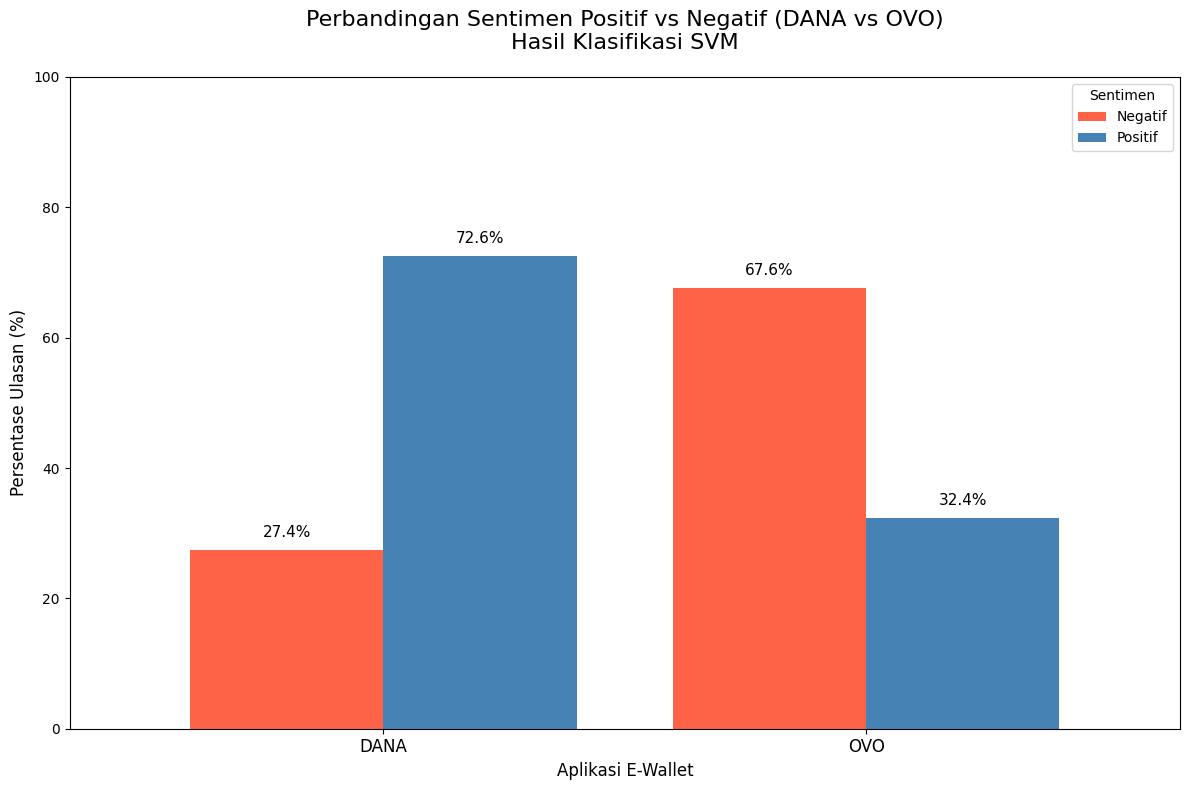

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Poin 1: Analisis Perbandingan DANA vs OVO ---
print("Memulai analisis perbandingan DANA vs OVO...")

# 1. Menghitung jumlah (absolut) dari hasil klasifikasi
comparison_counts = df.groupby('app_name')['hasil_ulasan_klasifikasi_svm'].value_counts().unstack().fillna(0)
print("\n--- Jumlah Sentimen (Absolut) DANA vs OVO ---")
print(comparison_counts)

# 2. Menghitung persentase untuk perbandingan yang adil
comparison_percentage = df.groupby('app_name')['hasil_ulasan_klasifikasi_svm'].value_counts(normalize=True).unstack().fillna(0) * 100
print("\n--- Persentase Sentimen DANA vs OVO ---")
print(comparison_percentage)

# --- 3. Visualisasi Perbandingan (Persentase) ---
print("\nMembuat visualisasi perbandingan...")

ax = comparison_percentage.plot(
    kind='bar',
    figsize=(12, 8),
    rot=0,
    width=0.8,
    color=['#FF6347', '#4682B4'] # Merah untuk 'negatif', Biru untuk 'positif'
)

plt.title('Perbandingan Sentimen Positif vs Negatif (DANA vs OVO)\nHasil Klasifikasi SVM', fontsize=16, pad=20)
plt.ylabel('Persentase Ulasan (%)', fontsize=12)
plt.xlabel('Aplikasi E-Wallet', fontsize=12)
plt.legend(title='Sentimen', loc='upper right', labels=['Negatif', 'Positif'])
plt.xticks(fontsize=12, ticks=[0, 1], labels=['DANA', 'OVO'])
plt.ylim(0, 100) # Set batas y dari 0 sampai 100

# Menambahkan label persentase di atas setiap bar
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0: # Hanya tampilkan label jika ada nilainya
        ax.text(x + width/2,
                y + height + 1.5, # Posisi 1.5 di atas bar
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=11)

plt.tight_layout()
plt.savefig('perbandingan_sentimen_dana_ovo.png')
print("Visualisasi perbandingan disimpan sebagai 'perbandingan_sentimen_dana_ovo.png'")

In [91]:
# Menyimpan Data Akhir
df.to_csv('/content/drive/MyDrive/SKRIPSI/CUST1/DATA/Hasil_klasifikasi_ulasan_Svm.csv', index = False)